# HateXplain – Analyse
Mathew et al. (2021) – dataset.json + post_id_divisions.json

20 148 poster fra Twitter og Gab, merket av 3 annotatorer per post med:
- `label`: `hatespeech`, `offensive` eller `normal`
- `target`: hvem innholdet retter seg mot (20+ grupper)
- `rationales`: hvilke tokens annotatorene uthevet som grunnlag

In [43]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import re
import string

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

True

## 1. Last inn og utforsk

In [44]:
with open("../data/dataset.json") as f:
    raw = json.load(f)

with open("../data/post_id_divisions.json") as f:
    splits = json.load(f)

print(f"Totalt antall poster: {len(raw)}")
print(f"Train: {len(splits['train'])}  Val: {len(splits['val'])}  Test: {len(splits['test'])}")

Totalt antall poster: 20148
Train: 15383  Val: 1922  Test: 1924


In [45]:
# Bygg DataFrame – flertall blant 3 annotatorer bestemmer klasse
label_map = {"hatespeech": 0, "offensive": 1, "normal": 2}

rows = []
for post_id, post in raw.items():
    labels = [a["label"] for a in post["annotators"]]
    majority = Counter(labels).most_common(1)[0][0]
    targets = [t for a in post["annotators"] for t in a["target"] if t != "None"]
    rows.append({
        "post_id":      post_id,
        "text":         " ".join(post["post_tokens"]),
        "label":        majority,
        "class":        label_map[majority],
        "targets":      targets,
        "disagreement": len(set(labels)) > 1,
        "has_rationale":len(post["rationales"]) > 0,
        "platform":     "twitter" if "twitter" in post_id else "gab"
    })

df = pd.DataFrame(rows)
print("Shape:", df.shape)
print("\nManglende verdier:")
print(df[["text", "class"]].isnull().sum())
df.head(3)

Shape: (20148, 8)

Manglende verdier:
text     0
class    0
dtype: int64


,post_id,text,label,class,targets,disagreement,has_rationale,platform
0,1179055004553900032_twitter,i dont think im getting my baby them white 9 h...,normal,2,[],False,False,twitter
1,1179063826874032128_twitter,we cannot continue calling ourselves feminists...,normal,2,[],False,False,twitter
2,1178793830532956161_twitter,nawt yall niggers ignoring me,normal,2,"[African, African]",True,False,twitter


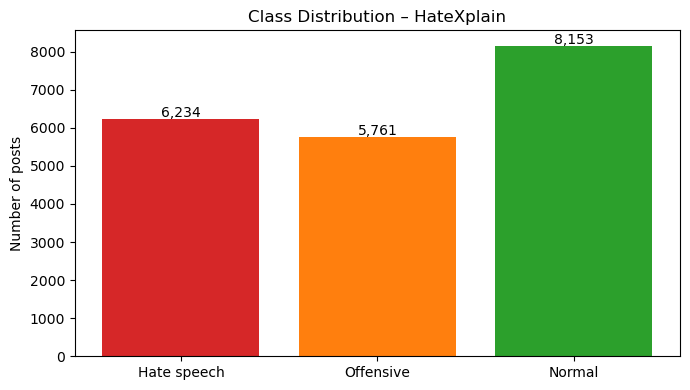

Hate speech    6234
Offensive      5761
Normal         8153


In [46]:
label_names = {0: "Hate speech", 1: "Offensive", 2: "Normal"}
counts = df["class"].value_counts().sort_index()
counts.index = [label_names[i] for i in counts.index]

plt.figure(figsize=(7, 4))
bars = plt.bar(counts.index, counts.values, color=["#d62728", "#ff7f0e", "#2ca02c"])
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f"{val:,}", ha="center", fontsize=10)
plt.title("Class Distribution – HateXplain")
plt.ylabel("Number of posts")
plt.tight_layout()
plt.show()
print(counts.to_string())

## 2. Annotator-uenighet og målgrupper

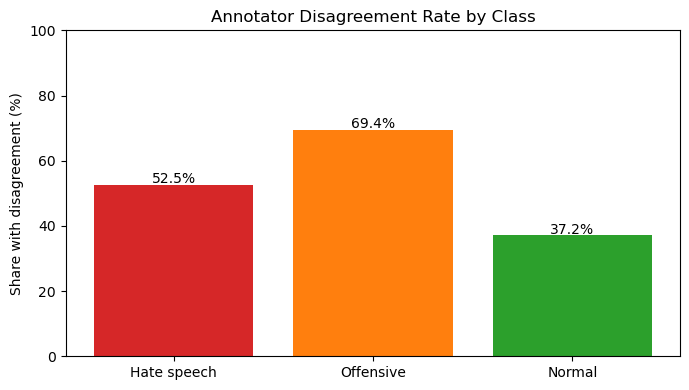

In [47]:
disagree_by_class = df.groupby("class")["disagreement"].mean() * 100
disagree_by_class.index = [label_names[i] for i in disagree_by_class.index]

plt.figure(figsize=(7, 4))
bars = plt.bar(disagree_by_class.index, disagree_by_class.values,
               color=["#d62728", "#ff7f0e", "#2ca02c"])
for bar, val in zip(bars, disagree_by_class.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", fontsize=10)
plt.title("Annotator Disagreement Rate by Class")
plt.ylabel("Share with disagreement (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

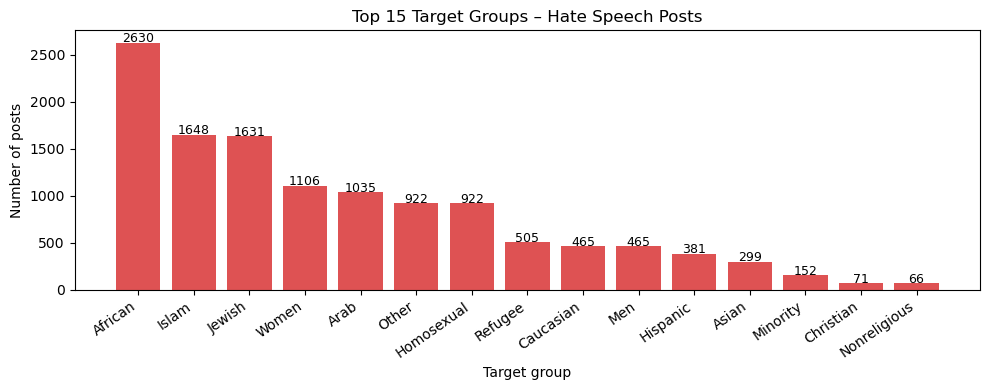

In [48]:
# Topp 15 target groups in hate speech posts (union per post to avoid annotator double-counting)
hate_df = df[df["class"] == 0].copy()
hate_targets = [t for targets in hate_df["targets"] for t in set(targets)]
target_counts = Counter(hate_targets).most_common(15)
labels_t, vals_t = zip(*target_counts)

plt.figure(figsize=(10, 4))
bars = plt.bar(labels_t, vals_t, color="#d62728", alpha=0.8)
for bar, val in zip(bars, vals_t):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             str(val), ha="center", fontsize=9)
plt.xlabel("Target group")
plt.ylabel("Number of posts")
plt.title("Top 15 Target Groups – Hate Speech Posts")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("../figurer/targeted_groups.pdf", bbox_inches="tight")

plt.show()

## 3. Forbehandling

In [49]:
stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"rt\s", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    tokens = [t for t in text.split() if t not in stop_words and len(t) > 1]
    return " ".join(tokens)

df["clean"] = df["text"].apply(preprocess)

print("Original: ", df["text"].iloc[1])
print("Cleaned:  ", df["clean"].iloc[1])

Original:  we cannot continue calling ourselves feminists if the rights of all womxn arent addressed yes to a sexual offences public list but will a trans lesbian bisexual and queer womxn be able to enter their information on the reporting sheet gender forum
Cleaned:   cannot continue calling feminists rights womxn arent addressed yes sexual offences public list trans lesbian bisexual queer womxn able enter information reporting sheet gender forum


## 4. TF-IDF og train/val/test-split

In [50]:
# Bruker de offisielle splittene fra post_id_divisions.json
df_indexed = df.set_index("post_id")

train_ids = [i for i in splits["train"] if i in df_indexed.index]
val_ids   = [i for i in splits["val"]   if i in df_indexed.index]
test_ids  = [i for i in splits["test"]  if i in df_indexed.index]

train_df = df_indexed.loc[train_ids]
val_df   = df_indexed.loc[val_ids]
test_df  = df_indexed.loc[test_ids]

# TF-IDF fittes kun på treningsdata for å unngå datalekkasje
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=20000, min_df=3)
X_train = tfidf.fit_transform(train_df["clean"])
X_val   = tfidf.transform(val_df["clean"])
X_test  = tfidf.transform(test_df["clean"])

y_train, y_val, y_test = train_df["class"], val_df["class"], test_df["class"]

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Train: (15383, 12846)  Val: (1922, 12846)  Test: (1924, 12846)


## 5. Logistisk regresjon

In [51]:
clf = LogisticRegression(max_iter=1000, class_weight="balanced", C=1.0,
                         solver="lbfgs", multi_class="multinomial")
clf.fit(X_train, y_train)

y_pred_lr = clf.predict(X_test)

print("=== Logistisk regresjon ===")
print(classification_report(
    y_test, y_pred_lr,
    target_names=["Hate speech (0)", "Offensive (1)", "Normal (2)"]
))

/Users/adnerolstad/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Logistisk regresjon ===
                 precision    recall  f1-score   support

Hate speech (0)       0.71      0.73      0.72       594
  Offensive (1)       0.50      0.49      0.50       548
     Normal (2)       0.69      0.68      0.69       782

       accuracy                           0.64      1924
      macro avg       0.63      0.64      0.63      1924
   weighted avg       0.64      0.64      0.64      1924



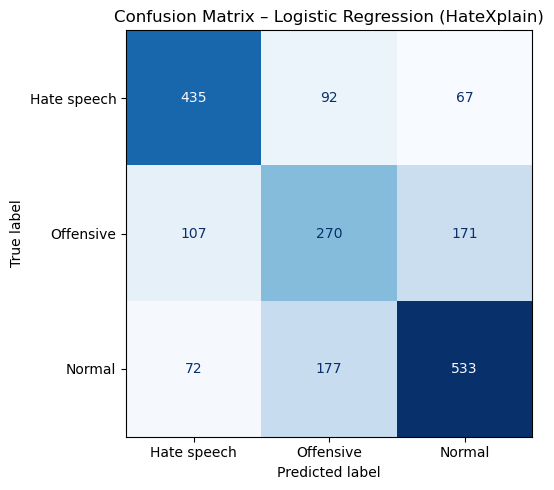

In [52]:
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Hate speech", "Offensive", "Normal"]
)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix – Logistic Regression (HateXplain)")
plt.tight_layout()
plt.show()

In [53]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy (logistic regression): {accuracy:.1%}")

Accuracy (logistic regression): 64.3%


## 6. Topp 15 features per klasse – logistisk regresjon

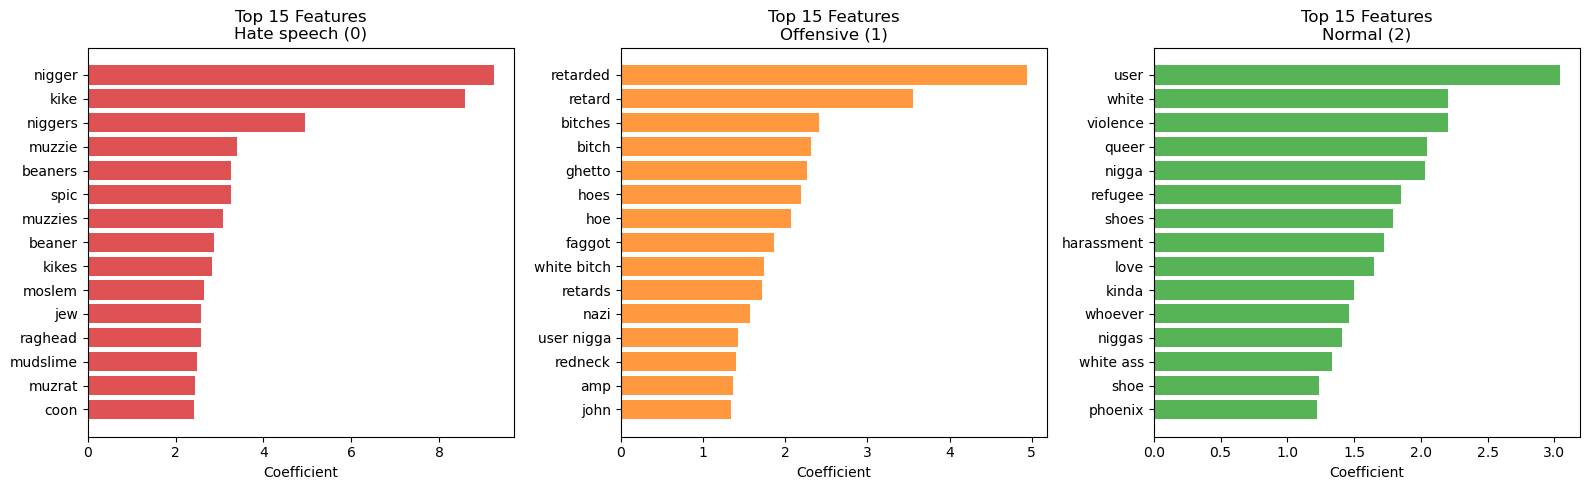

In [54]:
feature_names = np.array(tfidf.get_feature_names_out())
class_labels = ["Hate speech (0)", "Offensive (1)", "Normal (2)"]
colors = ["#d62728", "#ff7f0e", "#2ca02c"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (ax, label, color) in enumerate(zip(axes, class_labels, colors)):
    coef = clf.coef_[i]
    top_idx = np.argsort(coef)[-15:][::-1]
    ax.barh(range(15), coef[top_idx][::-1], color=color, alpha=0.8)
    ax.set_yticks(range(15))
    ax.set_yticklabels(feature_names[top_idx][::-1])
    ax.set_title(f"Top 15 Features\n{label}")
    ax.set_xlabel("Coefficient")
plt.tight_layout()
plt.savefig("../figurer/top_features_hatexplain_logreg.pdf", bbox_inches="tight")

plt.show()

## 7. Random Forest – trening og sammenligning

In [55]:
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(
    y_test, y_pred_rf,
    target_names=["Hate speech (0)", "Offensive (1)", "Normal (2)"]
))

f1_lr = f1_score(y_test, y_pred_lr, average="macro")
f1_rf = f1_score(y_test, y_pred_rf, average="macro")
print(f"Macro F1 – Logistisk regresjon : {f1_lr:.3f}")
print(f"Macro F1 – Random Forest       : {f1_rf:.3f}")

=== Random Forest ===
                 precision    recall  f1-score   support

Hate speech (0)       0.74      0.72      0.73       594
  Offensive (1)       0.59      0.40      0.48       548
     Normal (2)       0.64      0.80      0.71       782

       accuracy                           0.66      1924
      macro avg       0.66      0.64      0.64      1924
   weighted avg       0.66      0.66      0.65      1924

Macro F1 – Logistisk regresjon : 0.634
Macro F1 – Random Forest       : 0.640


## 8. Feature importance – Random Forest

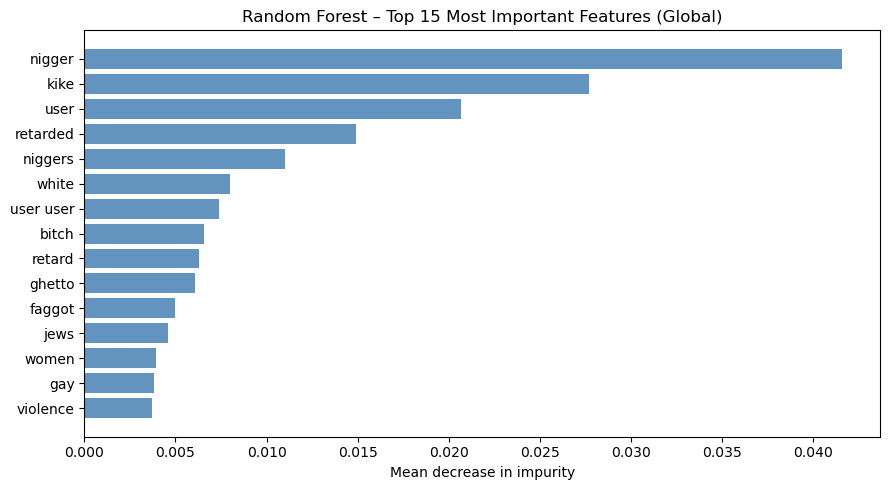

In [56]:
importances = rf.feature_importances_
top_global_idx = np.argsort(importances)[-15:][::-1]

plt.figure(figsize=(9, 5))
plt.barh(range(15), importances[top_global_idx][::-1], color="steelblue", alpha=0.85)
plt.yticks(range(15), feature_names[top_global_idx][::-1])
plt.xlabel("Mean decrease in impurity")
plt.title("Random Forest – Top 15 Most Important Features (Global)")
plt.tight_layout()
plt.show()

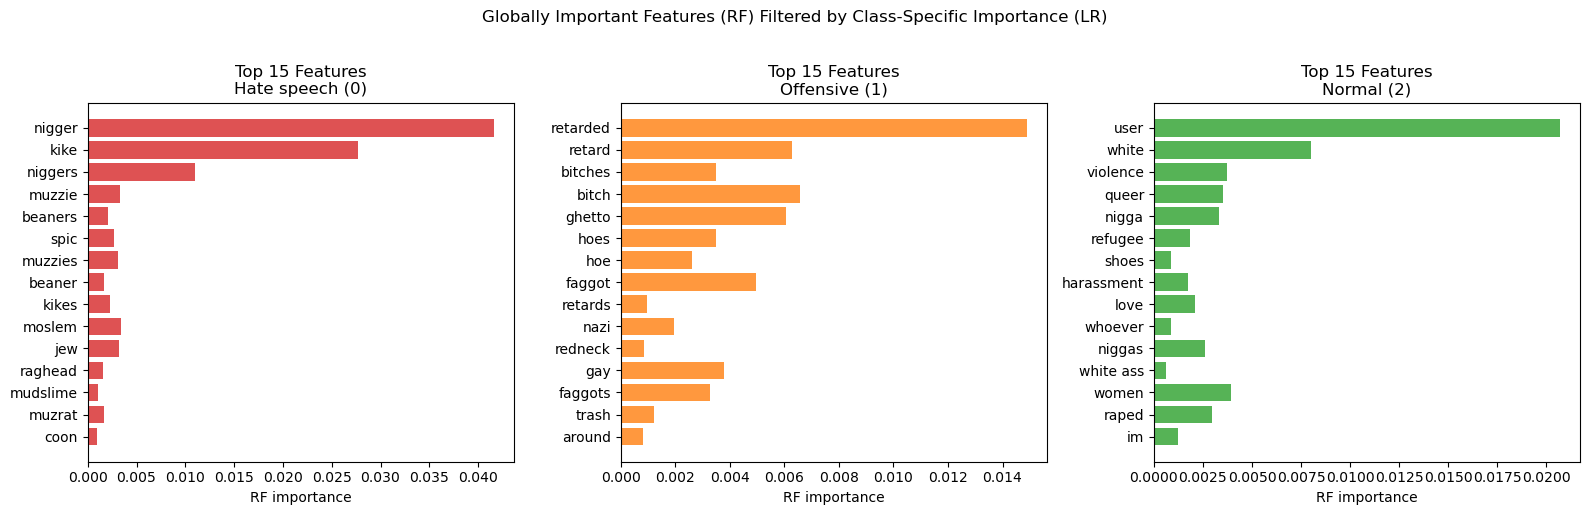

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (ax, label, color) in enumerate(zip(axes, class_labels, colors)):
    lr_coef = clf.coef_[i]
    top200_rf = np.argsort(importances)[-200:]
    top15_idx = top200_rf[np.argsort(lr_coef[top200_rf])[-15:][::-1]]
    ax.barh(range(15), importances[top15_idx][::-1], color=color, alpha=0.8)
    ax.set_yticks(range(15))
    ax.set_yticklabels(feature_names[top15_idx][::-1])
    ax.set_title(f"Top 15 Features\n{label}")
    ax.set_xlabel("RF importance")
plt.suptitle("Globally Important Features (RF) Filtered by Class-Specific Importance (LR)", y=1.02)
plt.tight_layout()
plt.savefig("../figurer/top_features_hatexplain_rf.pdf", bbox_inches="tight")

plt.show()

## 9. Hva HateXplain avdekker som Davidson ikke gjør

Over halvparten av postene har annotator-uenighet, og uenigheten er høyest for klasse 0 og 1 — nøyaktig der modellen sliter mest. Dette bekrefter at grensen mellom hat og offensivt innhold er genuine tvetydigheter, ikke støy.

**Målgruppe-dimensjonen** er det viktigste tillegget i dette datasettet: hate speech er ikke jevnt fordelt, men konsentrert mot spesifikke grupper. En bag-of-words-modell fanger ord, men ikke *hvem ordene rettes mot* — noe som er avgjørende for å skille hat fra generell banning.

**Relevans for Metas 2025-endringer:**
Metas liberalisering i januar 2025 åpnet for mer innhold rettet mot homofile og innvandrere — gruppene som topper målgruppeplottet her. Annotator-uenigheten viser at dette er innhold som selv mennesker klassifiserer ulikt. Når Meta hever terskelen for hva som fjernes, er det altså i et område der grensen allerede er diffus — og der automatiserte systemer har størst feilmargin.